## Web Scrapping y análisis de texto con Python

El objetivo de este cuaderno de jupyter es realizar una extrácción de datos desde una página web por medio de **WebScrapping** usando los paquetes requests y lxml. 

Para esto, se procederá a extraer la información desde el sitio web https://www.biblegateway.com centrándose en la extracción del capítulo 1 de Génesis, tanto en la versión Reina-Valera 1960 y la versión en ingles de la traducción The Message. Luego de eso, se realizará la extrácción del libro completo.

Finalmente, se realizará una limpieza de datos, eliminando los stopwords, y signos de puntuación para luego generar una nube de palabra para conocer las palabras de mayor uso.

### Extracción de datos

A continuación procederemos a usar los paquetes request y lxml para extraer información desde el sitio web https://www.biblegateway.com. Para esto procederemos a crear una función para scrapear un capítulo de la biblia.

In [551]:
# importar módulos
import requests
import lxml.html as html

In [569]:
# Función Scraper
def fn_scrapper_biblia(pagina):
    try: 
        # Requerir página web
        obtener_pagina = requests.get(pagina)
        # En caso de respuesta positíva al requerimiento de la página
        if obtener_pagina.status_code == 200:
            # Encoding página requerida a utf-8
            obtener_pagina_utf8 = obtener_pagina.content.decode('utf-8')
            # Parsear página 
            parsear_pagina = html.fromstring(obtener_pagina_utf8)
            # Obtener XPATH de los versiculos
            xpath_versiculos = '//p/span/@class'
            parsear_xpath_versiculos = parsear_pagina.xpath(xpath_versiculos)
            # Bucle for para capturar contenido de la ruta xpath de los versículos y unirlos en una lista
            capitulo_full = ["".join(parsear_pagina.xpath('//p/span[@class="'+versiculo+'"]/text()')) for versiculo in parsear_xpath_versiculos]
            # Unir los strings en uno sólo párrafo
            capitulo_full = " ".join(capitulo_full)
            # Quitar espacios extras
            capitulo_full = ' '.join(capitulo_full.split())
            return(capitulo_full)
        else:
            raise ValueError(f'Error:{respuesta.status}')
    except ValueError as ve:
        print(ve)

### Nube de palabras

Una vez obtenida la información (texto), prodecederos a generar una función para la generación de una nube de palabra. En este caso, excluiremos las stopwords y los signos de puntuación a fin de capturar la frcuencia de palabras claves presente en nuestro análisis.

In [578]:
# !pip -q install stop-words
# Importar módulo de stopwords
# !pip -q install wordcloud 

def fn_nube_palabra(texto, stop_words_idioma):

    # Importar módulo de stopwords
    from stop_words import get_stop_words 

    # Obtener lista de stopwords
    stop_words =  get_stop_words(stop_words_idioma)
    
    # Importar modulos WordCloud, STOPWORDS
    from wordcloud import WordCloud, STOPWORDS
    
    # Iniciar objeto nube de palabras
    obj_WordCloud = WordCloud(
        background_color='black',
        max_words=2000,
        stopwords=stop_words
    ).generate(texto)
    # Remover signos de puntuación a texto a analizar
    from punctuation import Punctuation
    texto = Punctuation.remove(texto)

    # Generar la nube de palabras
    #gen_1.generate(texto)

    # display the cloud
    fig = plt.figure()
    fig.set_figwidth(10) # set width
    fig.set_figheight(8) # set height

    plt.imshow(gen_1, interpolation='bilinear')
    plt.axis('off')
    plt.show()

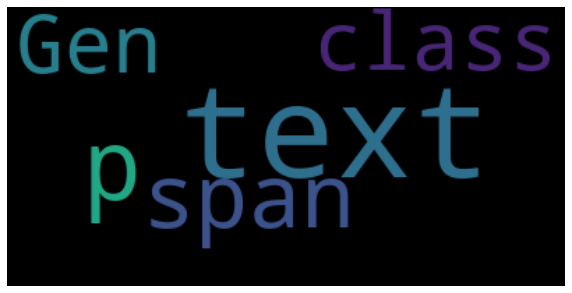

In [579]:
# Scrapper Génesis 1 RVR-60
url = 'https://www.biblegateway.com/passage/?search=G%C3%A9nesis+1&version=RVR1960'
# Usar función
genesis1_rv = fn_scrapper_biblia(url)
# Nube palabra
fn_nube_palabra(genesis1_rv, 'es')

In [525]:
from punctuation import Punctuation
from collections import Counter

split_genesis1_rv = Punctuation.remove(genesis1_rv)
split_genesis1_rv = split_genesis1_rv.split()
frecuencia = [word for word in split_genesis1_rv if word.lower() not in get_stop_words('es')]
frecuencia = Counter(frecuencia)
sorted(frecuencia.items(), key=lambda x:x[1], reverse=True)

[('Dios', 31),
 ('tierra', 20),
 ('aguas', 11),
 ('según', 10),
 ('cielos', 9),
 ('día', 9),
 ('expansión', 9),
 ('dijo', 7),
 ('vio', 7),
 ('luz', 6),
 ('tarde', 6),
 ('mañana', 6),
 ('así', 6),
 ('bueno', 6),
 ('semilla', 6),
 ('género', 6),
 ('toda', 6),
 ('creó', 5),
 ('llamó', 5),
 ('aves', 5),
 ('tinieblas', 4),
 ('hizo', 4),
 ('hierba', 4),
 ('fruto', 4),
 ('da', 4),
 ('Dijo', 3),
 ('verde', 3),
 ('árbol', 3),
 ('lumbreras', 3),
 ('noche', 3),
 ('especie', 3),
 ('bestias', 3),
 ('arrastra', 3),
 ('imagen', 3),
 ('faz', 2),
 ('separó', 2),
 ('Luego', 2),
 ('debajo', 2),
 ('seco', 2),
 ('Produzca', 2),
 ('dé', 2),
 ('separar', 2),
 ('alumbrar', 2),
 ('grandes', 2),
 ('lumbrera', 2),
 ('señorease', 2),
 ('seres', 2),
 ('vivientes', 2),
 ('bendijo', 2),
 ('Fructificad', 2),
 ('multiplicaos', 2),
 ('llenad', 2),
 ('animales', 2),
 ('animal', 2),
 ('hombre', 2),
 ('peces', 2),
 ('mar', 2),
 ('todas', 2),
 ('aquí', 2),
 ('planta', 2),
 ('comer', 2),
 ('principio', 1),
 ('desordenada', 

In [524]:
Punctuation.remove(genesis1_rv)

'En el principio creó Dios los cielos y la tierra Y la tierra estaba desordenada y vacía y las tinieblas estaban sobre la faz del abismo y el Espíritu de Dios se movía sobre la faz de las aguas Y dijo Dios Sea la luz y fue la luz Y vio Dios que la luz era buena y separó Dios la luz de las tinieblas Y llamó Dios a la luz Día y a las tinieblas llamó Noche Y fue la tarde y la mañana un día Luego dijo Dios Haya expansión en medio de las aguas y separe las aguas de las aguas E hizo Dios la expansión y separó las aguas que estaban debajo de la expansión de las aguas que estaban sobre la expansión Y fue así Y llamó Dios a la expansión Cielos Y fue la tarde y la mañana el día segundo Dijo también Dios Júntense las aguas que están debajo de los cielos en un lugar y descúbrase lo seco Y fue así Y llamó Dios a lo seco Tierra y a la reunión de las aguas llamó Mares Y vio Dios que era bueno Después dijo Dios Produzca la tierra hierba verde hierba que dé semilla árbol de fruto que dé fruto según su 

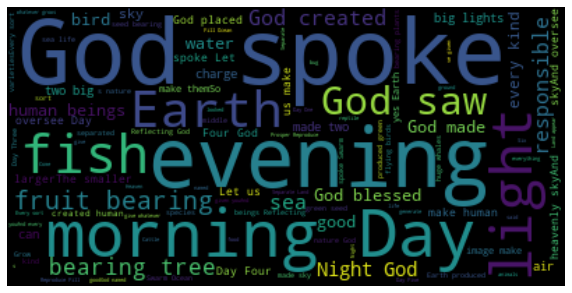

In [386]:
# Scrapper Génesis 1 The Message
url= 'https://www.biblegateway.com/passage/?search=Genesis+1&version=MSG'
# Usar función
genesis1_msg = fn_scrapper_biblia(url)
# Nube de palabras
fn_nube_palabra(genesis1_msg, 'en')

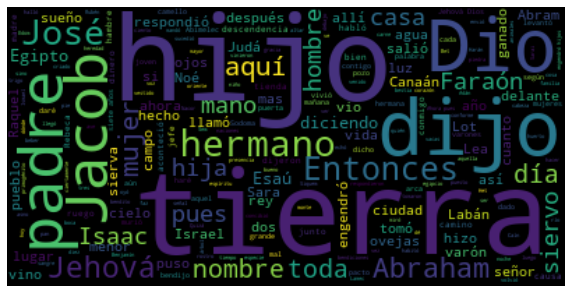

In [422]:
# Scraper Génesis RVR-60
genesis_rv = [fn_scrapper_biblia('https://www.biblegateway.com/passage/?search=G%C3%A9nesis+'+str(i)+'&version=RVR1960') for i in range(1,51)]
genesis_rv = ' '.join(genesis_rv)
fn_nube_palabra(genesis_rv, 'es')

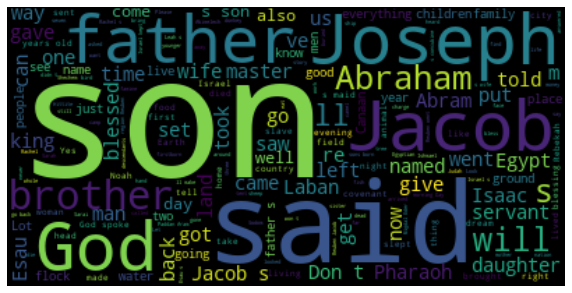

In [383]:
# Scraper Génesis The Message
genesis_msg = [fn_scrapper_biblia('https://www.biblegateway.com/passage/?search=G%C3%A9nesis+'+str(i)+'&version=MSG') for i in range(1,51)]
genesis_msg = ' '.join(genesis_msg)
fn_nube_palabra(genesis_msg, 'en')